# Relatorio de teste com logs Sysmon
Execute as celulas em ordem para gerar metricas, SHAP/LIME e o relatorio final.

In [1]:
import os
import sys
import subprocess
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import ipaddress
import joblib
import matplotlib.pyplot as plt

def ensure_package(import_name, pip_name=None):
    try:
        __import__(import_name)
        return
    except Exception:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

ensure_package("Evtx", "python-evtx")
ensure_package("shap")
ensure_package("lime")

from Evtx.Evtx import Evtx
import xml.etree.ElementTree as ET
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path("..").resolve()
MODEL_PATH = ROOT / "Train" / "modelo_ransomware.joblib"
DATASET_PATH = ROOT / "Datasets" / "LMD-2023-dataset.csv"

RANSOM_LOGS_DIR = ROOT / "RansomwaresLogs"
BENIGN_LOGS_DIR = ROOT / "ExesLogs"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert RANSOM_LOGS_DIR.exists(), f"Ransomware logs dir not found: {RANSOM_LOGS_DIR}"
assert BENIGN_LOGS_DIR.exists(), f"Benign logs dir not found: {BENIGN_LOGS_DIR}"

rf = joblib.load(MODEL_PATH)
rf

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [3]:
import sys
import joblib
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')

from parser.evtx_parser import parse_all_evtx
from parser.feature_engineering import extract_behavioral_features

# =========================================
# LOAD EVTX FILES
# =========================================

print("Parsing ransomware EVTX files...")

df_ransom_raw = parse_all_evtx(
    RANSOM_LOGS_DIR
)

df_ransom_raw["label"] = 1

print("Parsing benign EVTX files...")

df_benign_raw = parse_all_evtx(
    BENIGN_LOGS_DIR
)

df_benign_raw["label"] = 0

# =========================================
# CONCAT RAW LOGS
# =========================================

df_logs_raw = pd.concat(
    [df_ransom_raw, df_benign_raw],
    ignore_index=True
)

print(f"Total raw events: {len(df_logs_raw)}")

# =========================================
# FEATURE ENGINEERING
# =========================================

print("Extracting behavioral features...")

df_logs = extract_behavioral_features(
    df_logs_raw
)

print(f"Processes extracted: {len(df_logs)}")

# =========================================
# LABELS
# =========================================

y_logs = df_logs["label"]

# =========================================
# DROP NON-FEATURE COLUMNS
# =========================================

X_logs = df_logs.drop(
    columns=[
        "label",
        "process_key"
    ],
    errors="ignore"
)

# =========================================
# LOAD TRAIN FEATURE COLUMNS
# =========================================

feature_columns = joblib.load(
    ROOT / "Train" / "feature_columns.joblib"
)

# =========================================
# ALIGN FEATURES
# =========================================

X_logs = X_logs.reindex(
    columns=feature_columns,
    fill_value=0
)

print(f"Final feature shape: {X_logs.shape}")

# =========================================
# LOAD PREPROCESSOR
# =========================================

imputer = joblib.load(
    ROOT / "Train" / "preprocessor.joblib"
)

# =========================================
# PREPROCESS
# =========================================

X_logs_processed = pd.DataFrame(
    imputer.transform(X_logs),
    columns=X_logs.columns
)




INFO:root:4 EVTX files found
INFO:root:Parsing cerber.evtx


Parsing ransomware EVTX files...


INFO:root:Parsing locky.evtx
INFO:root:Parsing teslacrypt.evtx
INFO:root:Parsing wannacry.evtx
INFO:root:2 EVTX files found
INFO:root:Parsing Avast.evtx


Parsing benign EVTX files...


INFO:root:Parsing WindowsCredentialViewer.evtx
INFO:root:Starting robust feature engineering


Total raw events: 2089
Extracting behavioral features...
Grouping by: process_guid


INFO:root:Extracted features for 192 processes


Processes extracted: 192
Final feature shape: (192, 12)


In [4]:
# =========================================
# LOAD MODEL
# =========================================

rf = joblib.load(
    ROOT / "Train" / "modelo_ransomware.joblib"
)

# =========================================
# PREDICT
# =========================================

prob = rf.predict_proba(
    X_logs_processed
)[:, 1]

threshold = 0.2

pred = (
    prob >= threshold
).astype(int)

# =========================================
# SAVE RESULTS
# =========================================

df_logs["prediction"] = pred
df_logs["probability"] = prob

# =========================================
# METRICS
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_logs,
        pred
    )
)

cm = confusion_matrix(
    y_logs,
    pred
)

print("\nConfusion Matrx:\n")
print(cm)

acc = accuracy_score(
    y_logs,
    pred
)

print(f"\nAccuracy: {acc:.4f}")



Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.36      0.44        90
           1       0.58      0.77      0.66       102

    accuracy                           0.58       192
   macro avg       0.58      0.57      0.55       192
weighted avg       0.58      0.58      0.56       192


Confusion Matrx:

[[32 58]
 [23 79]]

Accuracy: 0.5781



Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.36      0.44        90
           1       0.58      0.77      0.66       102

    accuracy                           0.58       192
   macro avg       0.58      0.57      0.55       192
weighted avg       0.58      0.58      0.56       192


Confusion Matrix:

[[32 58]
 [23 79]]

Accuracy: 0.5781


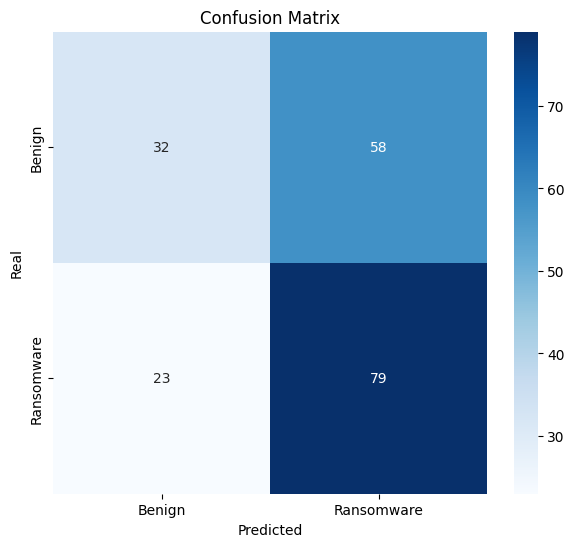

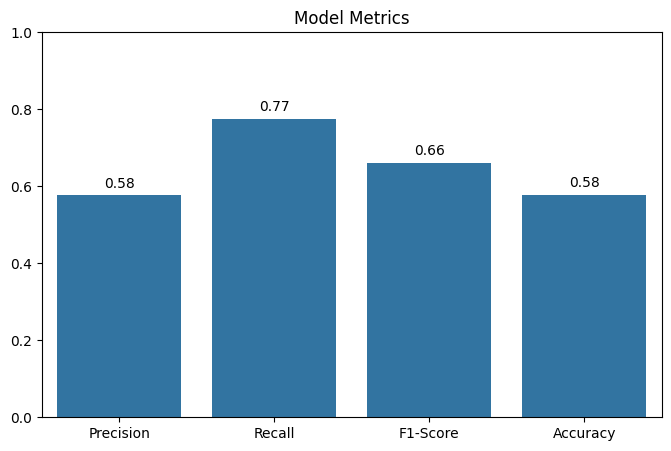

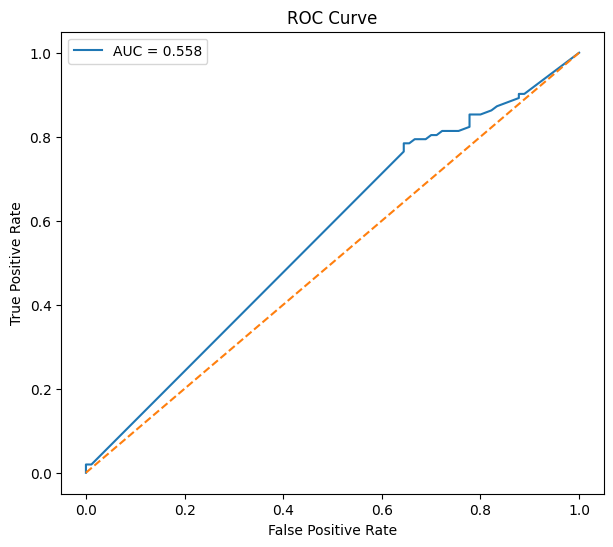

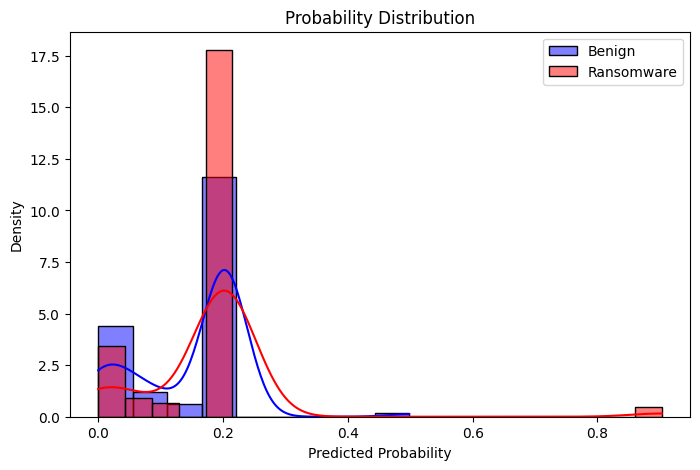

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)


# =========================================
# MÉTRICAS
# =========================================

cm = confusion_matrix(y_logs, pred)

precision = precision_score(y_logs, pred)
recall = recall_score(y_logs, pred)
f1 = f1_score(y_logs, pred)
acc = accuracy_score(y_logs, pred)

print("\nClassification Report:\n")
print(classification_report(y_logs, pred))

print("\nConfusion Matrix:\n")
print(cm)

print(f"\nAccuracy: {acc:.4f}")

# =========================================
# HEATMAP DA MATRIZ DE CONFUSÃO
# =========================================

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Ransomware'],
    yticklabels=['Benign', 'Ransomware']
)

plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")

plt.show()

# =========================================
# BARPLOT DAS MÉTRICAS
# =========================================

metrics = {
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Accuracy': acc
}

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

plt.ylim(0,1)

plt.title("Model Metrics")

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

# =========================================
# ROC CURVE
# =========================================

fpr, tpr, thresholds = roc_curve(y_logs, prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

# =========================================
# DISTRIBUIÇÃO DAS PROBABILIDADES
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    prob[y_logs == 0],
    color='blue',
    label='Benign',
    kde=True,
    stat='density'
)

sns.histplot(
    prob[y_logs == 1],
    color='red',
    label='Ransomware',
    kde=True,
    stat='density'
)

plt.legend()

plt.title("Probability Distribution")

plt.xlabel("Predicted Probability")

plt.show()

In [8]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_logs_processed.values,
    feature_names=X_logs_processed.columns.tolist(),
    class_names=["Benign", "Ransomware"],
    mode="classification"
)

print("LIME explainer criado")

LIME explainer criado


In [10]:
instance_idx = 0

exp = explainer.explain_instance(
    X_logs_processed.iloc[instance_idx].values,
    rf.predict_proba,
    num_features=10
)

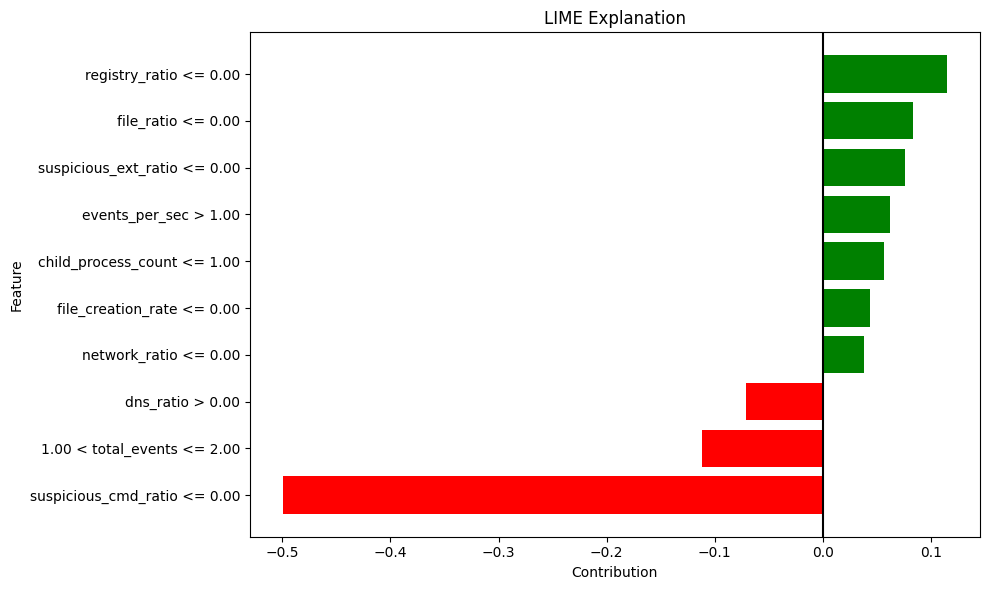

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

lime_df = pd.DataFrame(
    exp.as_list(),
    columns=[
        "feature",
        "contribution"
    ]
)

lime_df = lime_df.sort_values(
    by="contribution"
)

colors = [
    "red" if x < 0 else "green"
    for x in lime_df["contribution"]
]

plt.figure(figsize=(10,6))

plt.barh(
    lime_df["feature"],
    lime_df["contribution"],
    color=colors
)

plt.axvline(
    0,
    color="black"
)

plt.xlabel("Contribution")
plt.ylabel("Feature")

plt.title(
    "LIME Explanation"
)

plt.tight_layout()

plt.show()

In [12]:
import shap

explainer = shap.TreeExplainer(rf)

print("SHAP explainer criado")

SHAP explainer criado


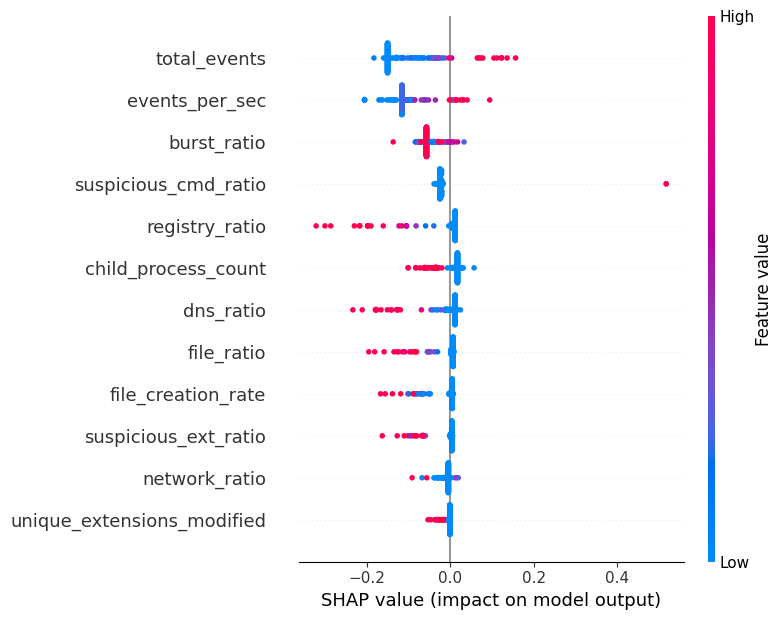

In [13]:
shap_values = explainer.shap_values(
    X_logs_processed
)

shap.summary_plot(
    shap_values[:, :, 1],
    X_logs_processed
)

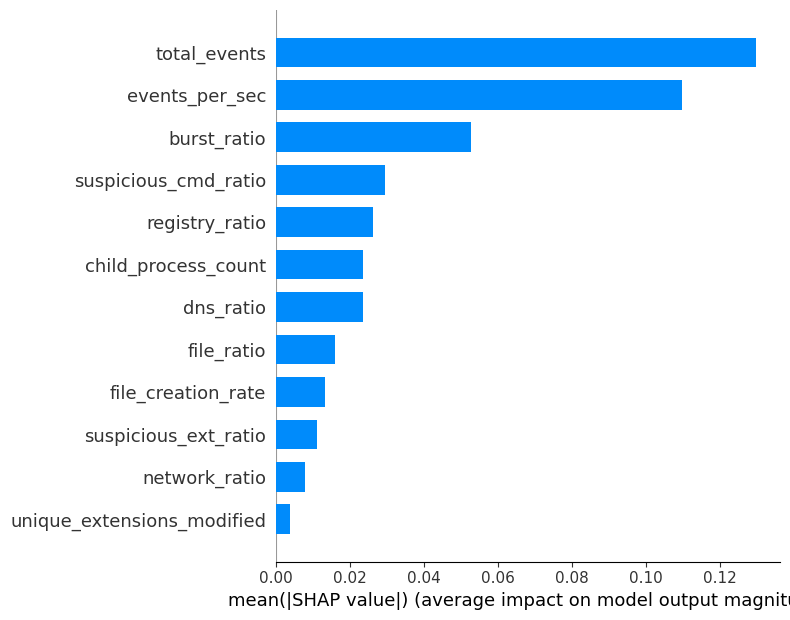

In [14]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_logs_processed,
    plot_type="bar"
)

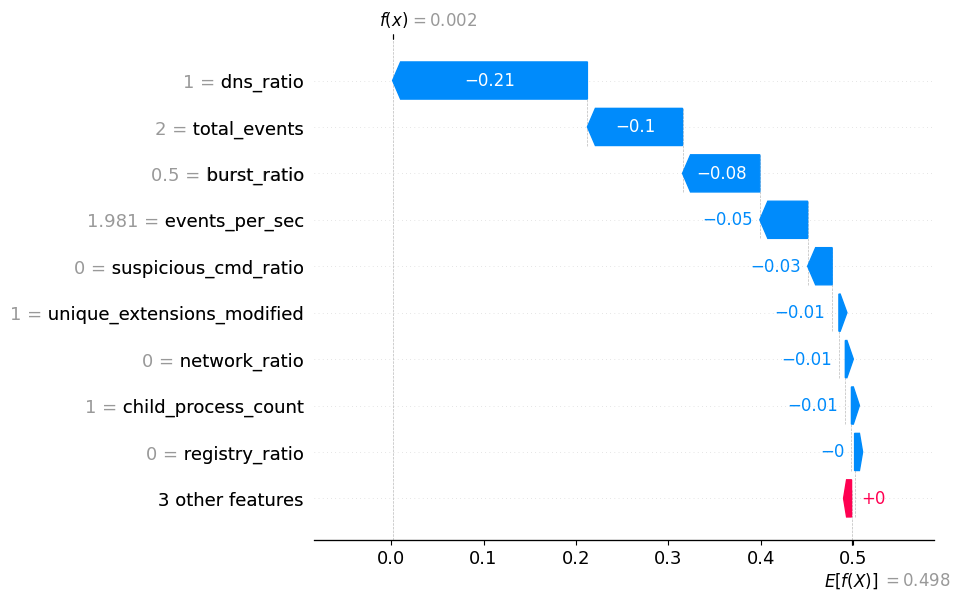

In [15]:
instance_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:, :, 1][instance_idx],
        base_values=explainer.expected_value[1],
        data=X_logs_processed.iloc[instance_idx],
        feature_names=X_logs_processed.columns
    )
)

In [17]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================
# PREDIÇÕES
# =========================================

threshold = 0.20

pred_logs = (
    prob >= threshold
).astype(int)

# =========================================
# MÉTRICAS
# =========================================

cm = confusion_matrix(
    y_logs,
    pred_logs
)

precision = precision_score(
    y_logs,
    pred_logs
)

recall = recall_score(
    y_logs,
    pred_logs
)

f1 = f1_score(
    y_logs,
    pred_logs
)

acc = accuracy_score(
    y_logs,
    pred_logs
)

auc_score = roc_auc_score(
    y_logs,
    prob
)

tn, fp, fn, tp = cm.ravel()

# =========================================
# RESULTADOS
# =========================================

print("=" * 60)
print("LOGS SYSMON REAIS - RESULTADOS")
print("=" * 60)

print(f"\nThreshold: {threshold}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_logs,
        pred_logs
    )
)

print("\nConfusion Matrix:\n")
print(cm)

print("\nMétricas:")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {auc_score:.4f}")

print("\nDetalhamento:")

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# =========================================
# TAXAS IMPORTANTES
# =========================================

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\nTaxas:")

print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")

# =========================================
# PROBABILIDADES
# =========================================

print("\nDistribuição das probabilidades:")

print(
    pd.Series(prob)
    .describe()
)

# =========================================
# FEATURE IMPORTANCE
# =========================================

importance_df = pd.DataFrame({
    "feature": X_logs_processed.columns,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 15 Features:\n")

print(
    importance_df.head(15)
)

# =========================================
# AMOSTRAS MAIS SUSPEITAS
# =========================================

df_results = df_logs.copy()

df_results["probability"] = prob
df_results["prediction"] = pred_logs

print("\nTop 10 processos mais suspeitos:\n")

print(
    df_results.sort_values(
        by="probability",
        ascending=False
    )[
        [
            "process_key",
            "probability",
            "prediction",
            "label"
        ]
    ].head(10)
)

LOGS SYSMON REAIS - RESULTADOS

Threshold: 0.2

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.36      0.44        90
           1       0.58      0.77      0.66       102

    accuracy                           0.58       192
   macro avg       0.58      0.57      0.55       192
weighted avg       0.58      0.58      0.56       192


Confusion Matrix:

[[32 58]
 [23 79]]

Métricas:
Accuracy : 0.5781
Precision: 0.5766
Recall   : 0.7745
F1-Score : 0.6611
ROC AUC  : 0.5584

Detalhamento:
True Negatives : 32
False Positives: 58
False Negatives: 23
True Positives : 79

Taxas:
False Positive Rate: 0.6444
False Negative Rate: 0.2255

Distribuição das probabilidades:
count    192.000000
mean       0.165110
std        0.111270
min        0.000000
25%        0.100000
50%        0.202681
75%        0.202681
max        0.903203
dtype: float64

Top 15 Features:

                       feature  importance
0                 total_events 